**The conference/seminar has been supported by the Postgraduate Students Conference/Seminar Grants of the Research Grants Council, Hong Kong.**

# Keyword & Semantic Network Analysis for Historical Texts
## Case Study 2: Palafox's *Historia de la Conquista de la China por el Tártaro* (1671)

**Workshop**: Keyword and Semantic Network Analysis Across Disciplines  
**Text**: EEBO-TCP A54677 — English edition (1671), 32 chapters  
**Research question**: How does computational reading reveal the narrative structure of Palafox's account of the Ming–Qing transition?

---
> **Note for participants**: Every manual input cell is clearly marked with `# MANUAL INPUT`.  
> All output values are computed from the actual text — no illustrative numbers are used.

## PART 0: Setup & Data Loading

In [ ]:
# PART 0 — Cell 1: Install libraries
!pip install -q networkx matplotlib pandas nltk scikit-learn

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✓ Setup complete")

✓ Setup complete


In [ ]:
# PART 0 — Cell 2: Import libraries
import re
import urllib.request
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

print("✓ Libraries imported")

✓ Libraries imported


In [ ]:
# PART 0 — Cell 3: ACCESSING FILES ONLINE
!pip install gdown

import os

# Ensure the target directory exists
os.makedirs(os.path.dirname(out_path), exist_ok=True)
print(f"✓ Created directory: {os.path.dirname(out_path)}")

import gdown

# Your share link:
url = "https://drive.google.com/file/d/1pUcnIPvy5H25JZif2e68k7olE3AOa-jG/view?usp=sharing"

# Extract the file ID from the link
file_id = "1pUcnIPvy5H25JZif2e68k7olE3AOa-jG"

# Construct a direct download URL
download_url = f"https://drive.google.com/uc?id={file_id}"

# Output path in Colab
out_path = "/content/data/palafox_1671_oxford_body.txt"

# Download
gdown.download(download_url, out_path, quiet=False)

print(f"✓ File saved to {out_path}")


✓ Created directory: /content/data


Downloading...
From: https://drive.google.com/uc?id=1pUcnIPvy5H25JZif2e68k7olE3AOa-jG
To: /content/data/palafox_1671_oxford_body.txt
100%|██████████| 598k/598k [00:00<00:00, 32.3MB/s]

✓ File saved to /content/data/palafox_1671_oxford_body.txt


In [ ]:
# PART 0 — Cell 4: Extract plain text from HTML

from html.parser import HTMLParser

class _TextExtractor(HTMLParser):
    def __init__(self):
        super().__init__()
        self._chunks = []
        self._skip   = False

    def handle_starttag(self, tag, attrs):
        if tag in ('script', 'style'):
            self._skip = True

    def handle_endtag(self, tag):
        if tag in ('script', 'style'):
            self._skip = False

    def handle_data(self, data):
        if not self._skip:
            self._chunks.append(data)

def html_to_text(path):
    with open(path, encoding='utf-8', errors='replace') as fh:
        raw = fh.read()
    parser = _TextExtractor()
    parser.feed(raw)
    text = ' '.join(parser._chunks)
    text = re.sub(r'Page \d+', '', text)          # remove page markers
    text = re.sub(r'\s+',      ' ', text).strip() # collapse whitespace
    return text

palafox_raw = html_to_text("/content/data/palafox_1671_oxford_body.txt")
print(f"✓ Text extracted: {len(palafox_raw):,} characters")
print("\nFirst 500 characters:")
print(palafox_raw[:500])

✓ Text extracted: 588,657 characters

First 500 characters:
CHAP. I. The Beginning of the Troubles of China. Two Subjects of the Emperour's rebell. They make themselves Msters of six Provinces, and of the Imperial Court. The Resolutions of the Tartars thereupon. CHAP. II. The Dath of the Emperour Zunchin, and of all the Royal Family. The Tartar resolves to oppose the Vsurper, and to advance his ancient Pretension to the Empire of China. CHAP. III. The Tartars enter into China. The Tyrant Ly flies. The young Xunchi makes his entrance into Pequin, and is t


In [ ]:
# PART 0 — Cell 5: Define chapter boundary patterns
# MANUAL INPUT: chapter boundaries based on EEBO-TCP A54677 structure
# Adjust patterns here if segmentation fails in Cell 6

CHAPTER_PATTERNS = [
    ( 1, r'CHAP\.\s*I\b'),
    ( 2, r'CHAP\.\s*II\b'),
    ( 3, r'CHAP\.\s*III\b'),
    ( 4, r'CHAP\.\s*IV\b'),
    ( 5, r'CHAP\.\s*V\b'),
    ( 6, r'CHAP\.\s*VI\b'),
    ( 7, r'CHAP\.\s*VII\b'),
    ( 8, r'CHAP\.\s*VIII\b'),
    ( 9, r'CHAP\.\s*IX\b'),
    (10, r'CHAP\.\s*X\b'),
    (11, r'CHAP\.\s*XI\b'),
    (12, r'CHAP\.\s*XII\b'),
    (13, r'CHAP\.\s*XIII\b'),
    (14, r'CHAP\.\s*XIV\b'),
    (15, r'CHAP\.\s*XV\b'),
    (16, r'CHAP\.\s*XVI\b'),
    (17, r'CHAP\.\s*XVII\b'),
    (18, r'CHAP\.\s*XVIII\b'),
    (19, r'CHAP\.\s*XIX\b'),
    (20, r'CHAP\.\s*XX\b'),
    (21, r'CHAP\.\s*XXI\b'),
    (22, r'CHAP\.\s*XXII\b'),
    (23, r'CHAP\.\s*XXIII\b'),
    (24, r'CHAP\.\s*XXIV\b'),
    (25, r'CHAP\.\s*XXV\b'),
    (26, r'CHAP\.\s*XXVI\b'),
    (27, r'CHAP\.\s*XXVII\b'),
    (28, r'CHAP\.\s*XXVIII\b'),
    (29, r'CHAP\.\s*XXIX\b'),
    (30, r'CHAP\.\s*XXX\b'),
    (31, r'CHAP\.\s*XXXI\b'),
    (32, r'CHAP\.\s*XXXII\b'),
]

print(f"✓ Chapter patterns defined: {len(CHAPTER_PATTERNS)} chapters expected")

✓ Chapter patterns defined: 32 chapters expected


In [ ]:
# PART 0 — Cell 6: Segment text into chapters
#
# IMPORTANT — why we use finditer() and take the LAST match:
# EEBO-TCP texts open with a Table of Contents that lists every chapter heading
# once before the body text begins.  re.search() finds the FIRST occurrence,
# which is the TOC entry — a one-line index item, not the chapter body.
# re.finditer() finds ALL occurrences; taking the last one skips the TOC
# and lands on the actual chapter start in the body.

def segment_chapters(text, chapter_patterns):
    """
    Return dict {chapter_number: chapter_text} using regex boundaries.

    For each pattern, all matches are found with finditer() and the LAST
    match is used to skip Table-of-Contents entries that appear before the
    body text in EEBO-TCP documents.
    """
    positions = []
    for chap_num, pattern in chapter_patterns:
        matches = list(re.finditer(pattern, text, re.IGNORECASE))
        if matches:
            # Take the last match to skip the TOC occurrence
            last_match = matches[-1]
            positions.append((chap_num, last_match.start()))
        else:
            print(f"  ⚠ Pattern not found for Chapter {chap_num}: {pattern}")

    # Sort by position in the text (preserves narrative order)
    positions.sort(key=lambda x: x[1])

    chapters = {}
    for i, (chap_num, start) in enumerate(positions):
        end = positions[i + 1][1] if i < len(positions) - 1 else len(text)
        chapters[chap_num] = text[start:end].strip()

    return chapters

chapters = segment_chapters(palafox_raw, CHAPTER_PATTERNS)
print(f"✓ Extracted {len(chapters)} chapters")
print()
print(f"{'Chapter':<12} {'Words':>6}")
print("-" * 20)
for num in sorted(chapters.keys()):
    wc = len(chapters[num].split())
    print(f"Chapter {num:<4} {wc:>6}")


✓ Extracted 32 chapters

Chapter       Words
--------------------
Chapter 1      3879
Chapter 2      6116
Chapter 3      3141
Chapter 4      2685
Chapter 5      2391
Chapter 6      5292
Chapter 7      3769
Chapter 8      3502
Chapter 9      3215
Chapter 10     3106
Chapter 11     3906
Chapter 12     1869
Chapter 13     2801
Chapter 14     2560
Chapter 15     2648
Chapter 16     2330
Chapter 17     3394
Chapter 18     2830
Chapter 19     1937
Chapter 20     3039
Chapter 21     1821
Chapter 22      847
Chapter 23     2322
Chapter 24     4886
Chapter 25     1960
Chapter 26     3218
Chapter 27     5095
Chapter 28     3032
Chapter 29     2165
Chapter 30     2781
Chapter 31     3134
Chapter 32     4138


---
## CHECKPOINT 0

- **Do you see 32 chapters?**
- **Do word counts look reasonable (roughly 500–6,000 words each)?**
- If chapters are missing or counts look wrong, return to Cell 5 and adjust the `CHAPTER_PATTERNS` regex list.

> Tip: if a pattern like `CHAP. VIII` is not matching, the source may use `Chap. VIII` (mixed case) — the `re.IGNORECASE` flag handles this, but check the raw HTML if needed.

---
## PART 1: Apply Tianai's Approach — Baseline Network

We apply the **same preprocessing and co-occurrence network logic** used in Case Study 1 (Flickr30k dog captions) directly to Chapter 8 of the *Historia*.  
This is our starting point — a first pass before adapting the method to historical questions.

In [ ]:
# PART 1 — Cell 8: Define stopwords
# MANUAL INPUT: domain-specific stopwords added to NLTK English base list

BASE_STOPWORDS   = set(stopwords.words('english'))

# Early Modern English function words and high-frequency discourse markers
# to remove words that carry no historiographic content
CUSTOM_STOPWORDS = {
    'shall', 'would', 'could', 'might', 'must',
    'said', 'upon', 'therefore', 'thus', 'though',
    'amongst', 'wherein', 'thereby', 'hath', 'doth',
    'also', 'yet', 'still', 'even', 'much', 'great',
    'made', 'came', 'went', 'came', 'took', 'gave',
}

ALL_STOPWORDS = BASE_STOPWORDS | CUSTOM_STOPWORDS

print(f"✓ Stopwords defined: {len(BASE_STOPWORDS)} base + "
      f"{len(CUSTOM_STOPWORDS)} custom = {len(ALL_STOPWORDS)} total")

✓ Stopwords defined: 198 base + 26 custom = 224 total


In [ ]:
# PART 1 — Cell 9: Define preprocessing function and test on Chapter 8

def preprocess_text(text, stop_words=ALL_STOPWORDS):
    """Lowercase, remove punctuation, tokenize, filter stopwords and short words."""
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    text   = re.sub(r'\s+',      ' ', text)
    tokens = text.split()
    return [w for w in tokens if w not in stop_words and len(w) > 2]

# Test on Chapter 8 (Icoan taken prisoner, presented to Qing emperor)
#test_chap = 8 if 8 in chapters else sorted(chapters.keys())[0]

if 8 in chapters:
    test_chap = 8
elif chapters:
    test_chap = sorted(chapters.keys())[0]
else:
    raise ValueError("No chapters available to preprocess.")


tokens_ch8 = preprocess_text(chapters[test_chap])

print(f"✓ Preprocessing test on Chapter {test_chap}")
print(f"Total content words: {len(tokens_ch8):,}")
print(f"\nFirst 50 tokens:")
print(tokens_ch8[:50])

✓ Preprocessing test on Chapter 8
Total content words: 1,334

First 50 tokens:
['chap', 'viii', 'icoan', 'demands', 'succour', 'emperour', 'japan', 'refuses', 'maintains', 'war', 'tartars', 'whole', 'year', 'taken', 'prisoner', 'presented', 'emperour', 'xunchi', 'end', 'corsair', 'icoan', 'understood', 'well', 'concern', 'answer', 'returned', 'viceroy', 'nanquin', 'expected', 'fury', 'triumphant', 'enemy', 'presently', 'thunder', 'mustered', 'forces', 'prepared', 'receive', 'assaults', 'enemies', 'negligent', 'thing', 'judged', 'convenient', 'send', 'embassie', 'emperor', 'iapan', 'demand', 'succour']


In [ ]:
# PART 1 — Cell 10: Keyword frequency function and Chapter 8 results

def get_keyword_frequencies(tokens, top_n=30):
    """Return list of (word, count) tuples sorted by frequency."""
    return Counter(tokens).most_common(top_n)

chap_test_kw = get_keyword_frequencies(tokens_ch8, top_n=30)

print(f"TOP 30 KEYWORDS — CHAPTER {test_chap}")
print("=" * 40)
for word, count in chap_test_kw:
    print(f"  {word:<20} {count:>4}")

TOP 30 KEYWORDS — CHAPTER 8
  icoan                  27
  prince                 15
  china                  14
  provinces              13
  king                   13
  emperour               12
  tartars                12
  never                  10
  time                    9
  nanquin                 8
  court                   8
  unkle                   8
  pelipaouan              8
  well                    7
  nothing                 7
  men                     7
  province                7
  xunchi                  6
  viceroy                 6
  enemies                 6
  iapan                   6
  kings                   6
  first                   6
  young                   6
  war                     5
  whole                   5
  taken                   5
  prisoner                5
  answer                  5
  judged                  5


In [ ]:
# PART 1 — Cell 11: Build co-occurrence network function (mirrors Tianai's approach)

def build_cooccurrence_network(tokens, window_size=20, min_cooccur=2):
    """
    Build undirected graph where edges connect words co-occurring
    within a sliding window.  Mirrors the approach in Case Study 1.
    """
    G       = nx.Graph()
    G.add_nodes_from(set(tokens))
    cooccur = defaultdict(int)

    for i in range(len(tokens)):
        window = tokens[i: i + window_size]
        for j, word1 in enumerate(window):
            for word2 in window[j + 1:]:
                if word1 != word2:
                    pair = tuple(sorted([word1, word2]))
                    cooccur[pair] += 1

    for (w1, w2), weight in cooccur.items():
        if weight >= min_cooccur:
            G.add_edge(w1, w2, weight=weight)

    return G

# Test on Chapter 8 tokens
network_ch8 = build_cooccurrence_network(tokens_ch8)

print(f"✓ Network built for Chapter {test_chap}")
print(f"  Nodes (unique content words): {network_ch8.number_of_nodes():,}")
print(f"  Edges (co-occurrence pairs):  {network_ch8.number_of_edges():,}")

✓ Network built for Chapter 8
  Nodes (unique content words): 790
  Edges (co-occurrence pairs):  20,286


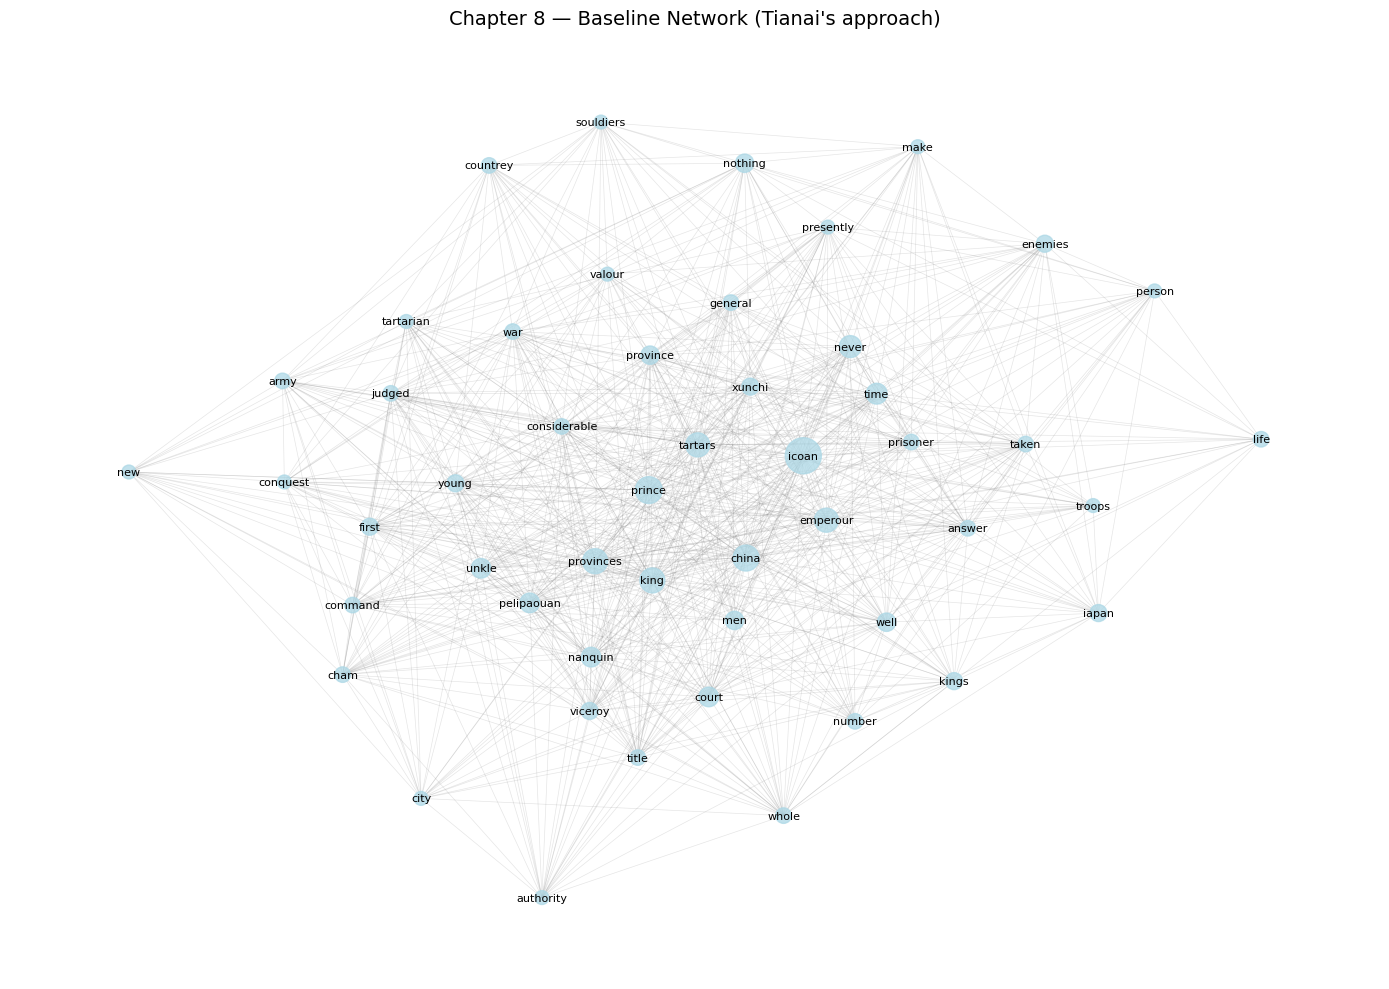

✓ Network visualised: 50 nodes, 768 edges
  Note: layout algorithm may vary — structure matters, not exact positions


In [ ]:
# PART 1 — Cell 12: Visualize Chapter 8 baseline network

def visualize_network(G, tokens, title, top_n=50, node_color='lightblue'):
    """
    Draw top_n most-frequent nodes with size proportional to frequency.
    Note: spring_layout seed=42 ensures reproducible layout,
    but absolute node positions carry no meaning — structure matters.
    """
    freq      = Counter(tokens)
    top_nodes = [w for w, _ in freq.most_common(top_n)]
    G_sub     = G.subgraph(top_nodes).copy()
    G_sub.remove_nodes_from(list(nx.isolates(G_sub)))

    pos        = nx.spring_layout(G_sub, k=0.6, seed=42)
    node_sizes = [freq[n] * 25 for n in G_sub.nodes()]

    plt.figure(figsize=(14, 10))
    nx.draw_networkx_edges(G_sub, pos, alpha=0.2, width=0.5, edge_color='gray')
    nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes,
                           node_color=node_color, alpha=0.75)
    nx.draw_networkx_labels(G_sub, pos, font_size=8)
    plt.title(title, fontsize=14, pad=12)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"data/network_baseline_ch{test_chap}.png", dpi=150)
    plt.show()
    print(f"✓ Network visualised: {G_sub.number_of_nodes()} nodes, "
          f"{G_sub.number_of_edges()} edges")
    print("  Note: layout algorithm may vary — structure matters, not exact positions")

visualize_network(network_ch8, tokens_ch8,
                  f"Chapter {test_chap} — Baseline Network (Tianai's approach)")

---
## CHECKPOINT 1

- **What do you see in the network?**
- **For Chapter 8: are *icoan*, *hollanders*, *macao* visible as prominent nodes?**
- **Is the network dense / hard to read?** This is expected — we have not yet filtered by entity type or historical relevance.
- **This is the baseline.** The next steps adapt the method to address historical questions.

> Compare with Case Study 1: Tianai's caption-level network clusters verbs into coherent action groups.  
> Here we have a richer but noisier picture — because a 100,000-word historical narrative is not a controlled experiment.

---
## PART 2: Segmentation Matters — Units of Analysis

> **Key difference from Case Study 1**: Tianai's captions are atomic units by experimental design.  
> For a historical text, *we* choose how to segment — and that choice determines what patterns emerge.

In [ ]:
# PART 2 — Cell 14: Global vs. chapter-level keyword comparison
# Preprocessing all chapters (takes ~1 min for full text)

# Build token lists per chapter
chapter_tokens = {num: preprocess_text(chapters[num])
                  for num in sorted(chapters.keys())}

# Global: all tokens combined
all_tokens   = [tok for toks in chapter_tokens.values() for tok in toks]
global_kw    = get_keyword_frequencies(all_tokens,              top_n=10)

# Three focal chapters
ch2_kw  = get_keyword_frequencies(chapter_tokens.get(2,  []), top_n=10)
ch8_kw  = get_keyword_frequencies(chapter_tokens.get(8,  []), top_n=10)
ch6_kw = get_keyword_frequencies(chapter_tokens.get(6, []), top_n=10)

def _print_block(label, kw_list):
    print(label)
    print("-" * 45)
    for word, count in kw_list:
        print(f"  {word:<20} {count:>4}")
    print()

_print_block("GLOBAL TOP 10 KEYWORDS  (Entire Text)",          global_kw)
_print_block("CHAPTER 2  TOP 10 KEYWORDS  (Ming Fall)",        ch2_kw)
_print_block("CHAPTER 8  TOP 10 KEYWORDS  (Icoan / Maritime)", ch8_kw)
_print_block("CHAPTER 6 TOP 10 KEYWORDS  (Maritime2)",         ch6_kw)

GLOBAL TOP 10 KEYWORDS  (Entire Text)
---------------------------------------------
  tartars               421
  china                 291
  chineses              224
  time                  209
  make                  207
  prince                187
  city                  184
  persons               169
  one                   168
  people                155

CHAPTER 2  TOP 10 KEYWORDS  (Ming Fall)
---------------------------------------------
  empire                 31
  china                  30
  prince                 28
  emperour               22
  tyrant                 21
  death                  17
  zunchin                16
  royal                  16
  time                   15
  state                  14

CHAPTER 8  TOP 10 KEYWORDS  (Icoan / Maritime)
---------------------------------------------
  icoan                  27
  prince                 15
  china                  14
  provinces              13
  king                   13
  emperour               12
  tarta

In [ ]:
# PART 2 — Cell 15: Build segmentation comparison table and save

def _top5_fmt(kw_list):
    """Format top-5 keyword list as 'word (count)' strings."""
    return [f"{w} ({c})" for w, c in kw_list[:5]]

comparison_df = pd.DataFrame({
    'Rank':   list(range(1, 6)),
    'Global': _top5_fmt(global_kw),
    'Ch 2 (Ming Fall)':  _top5_fmt(ch2_kw),
    'Ch 8 (Maritime)':   _top5_fmt(ch8_kw),
})

print("SEGMENTATION COMPARISON — TOP 5 KEYWORDS PER UNIT")
print("=" * 65)
print(comparison_df.to_string(index=False))

comparison_df.to_csv("data/segmentation_comparison.csv", index=False)
print("\n✓ Saved to data/segmentation_comparison.csv")

SEGMENTATION COMPARISON — TOP 5 KEYWORDS PER UNIT
 Rank         Global Ch 2 (Ming Fall) Ch 8 (Maritime)
    1  tartars (421)      empire (31)      icoan (27)
    2    china (291)       china (30)     prince (15)
    3 chineses (224)      prince (28)      china (14)
    4     time (209)    emperour (22)  provinces (13)
    5     make (207)      tyrant (21)       king (13)

✓ Saved to data/segmentation_comparison.csv


---
## CHECKPOINT 2

- **Global keywords**: pervasive actors and concepts (tartars, china, prince…) — the book's spine
- **Chapter 2**: political-tragedy vocabulary (emperor, zunchin, death, sorrow…)
- **Chapter 8**: maritime-commercial vocabulary (icoan, hollanders, macao…)
- **Chapter 22**: strikingly different — sensory and prophetic vocabulary (eyes, blew, prophecy…)

> **NOTE**: Segmentation reveals thematic shifts invisible at global level.  
> Chapters are not arbitrary — they reflect Palafox's own authorial structure.  
> Choosing the unit of analysis is a methodological decision, not a neutral step.

---
## PART 3: Keywords Beyond Arbitrary Selection — TF-IDF + Validation

> **Problem**: how do we select keywords without just confirming what we already believe?  
> In Case Study 1, top-frequency verbs are the natural choice for action concepts.  
> For history, keywords could be anything. We need a **disciplined, evidence-driven** method.

In [ ]:
# PART 3 — Cell 17: TF-IDF computation
# TF-IDF rewards words frequent in ONE chapter but rare across others
# We focus on Chapter 7 — Icoan's treaty with the Hollanders and
# quarrel with the Portuguese of Macao — directly relevant to
# maritime networks and early globalization

chapter_strings = [' '.join(chapter_tokens[num])
                   for num in sorted(chapter_tokens.keys())]
chapter_numbers = sorted(chapter_tokens.keys())

vectorizer    = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_matrix  = vectorizer.fit_transform(chapter_strings)
feature_names = vectorizer.get_feature_names_out()

ch7_idx   = chapter_numbers.index(7)
ch7_vec   = tfidf_matrix[ch7_idx].toarray()[0]
top_idx   = ch7_vec.argsort()[::-1][:10]

print("CHAPTER 7 — TOP 10 DISTINCTIVE TERMS (TF-IDF)")
print("(Icoan's treaty with Hollanders / quarrel with Macao)")
print("=" * 50)
for idx in top_idx:
    print(f"  {feature_names[idx]:<20} {ch7_vec[idx]:.4f}")

print()
print("Note: score reflects distinctiveness to Ch.7 relative to all other chapters")


CHAPTER 7 — TOP 10 DISTINCTIVE TERMS (TF-IDF)
(Icoan's treaty with Hollanders / quarrel with Macao)
  icoan                0.7229
  hollanders           0.2129
  king                 0.1770
  christian            0.1727
  china                0.1653
  portuguezes          0.1591
  macao                0.1522
  prince               0.1229
  iapan                0.1086
  nanquin              0.0979

Note: score reflects distinctiveness to Ch.7 relative to all other chapters


In [ ]:
# PART 3 — Cell 18: KWIC validation on maritime/trade terms
# MANUAL VALIDATION: does TF-IDF flag meaningful maritime passages?
# We check Chapter 7 for terms directly relevant to trade networks
# and commercial competition — the focus of this case study

def kwic(text, keyword, window=80, max_hits=5):
    """Print keyword-in-context (window characters either side)."""
    pattern = re.compile(re.escape(keyword), re.IGNORECASE)
    hits    = list(pattern.finditer(text))[:max_hits]
    if not hits:
        print(f"  ['{keyword}' not found in this chapter]")
        return
    for i, m in enumerate(hits, 1):
        start   = max(0, m.start() - window)
        end     = min(len(text), m.end() + window)
        snippet = text[start:end].replace('\n', ' ')
        print(f"  {i}. ...{snippet}...")

ch7_text = chapters.get(7, "")

print("KWIC for 'trade' in Chapter 7:")
print("-" * 60)
kwic(ch7_text, 'trade')

print("\nKWIC for 'hollanders' in Chapter 7:")
print("-" * 60)
kwic(ch7_text, 'hollanders')

print("\nKWIC for 'macao' in Chapter 7:")
print("-" * 60)
kwic(ch7_text, 'macao')


KWIC for 'trade' in Chapter 7:
------------------------------------------------------------
  1. ...ld exclude them from the greatest profit and advantage which they made by their Trade to the Indies. The Hollanders, should they be deprived of Liberty to trade with...
  2. ...heir Trade to the Indies. The Hollanders, should they be deprived of Liberty to trade with China, would lose a great part of their Treasure; for they meet in no part...
  3. ...gh it was bound for their Enemies Countrey, and hereby did much prejudice their Trade; and all this they did solely out of consideration to Icoan ; for if they met w...
  4. ...t thus pilfered. All this they passed over, being desirous to continue on their Trade, though it was with the less profit. For several years together there was nothi...

KWIC for 'hollanders' in Chapter 7:
------------------------------------------------------------
  1. ...CHAP. VII. The Pyrate Icoan made a Treaty with the Hollanders. His Quarrel with the Portuguese

In [ ]:
# PART 3 — Cell 19: Frequency vs. TF-IDF comparison table

global_top5    = [w for w, _ in global_kw[:5]]
global_counts  = [c for _, c in global_kw[:5]]

ch7_top5      = [feature_names[i] for i in top_idx[:5]]
ch7_scores    = [f"{ch7_vec[i]:.4f}" for i in top_idx[:5]]

comparison2_df = pd.DataFrame({
    'Rank':                    list(range(1, 6)),
    'Global Frequency':        [f"{w} ({c})" for w, c in zip(global_top5, global_counts)],
    'Ch 7 TF-IDF (distinctive)': [f"{w} ({s})" for w, s in zip(ch7_top5, ch7_scores)],
})

print("FREQUENCY vs. TF-IDF COMPARISON")
print("=" * 65)
print(comparison2_df.to_string(index=False))

# Interpretation comments (for display)
print()
print("Frequency alone: text is about Tartars/China — obvious from the title")
print("TF-IDF flags Ch.7: Maritime Trade")

comparison2_df.to_csv("data/frequency_vs_tfidf.csv", index=False)
print("\n✓ Saved to data/frequency_vs_tfidf.csv")

FREQUENCY vs. TF-IDF COMPARISON
 Rank Global Frequency Ch 7 TF-IDF (distinctive)
    1    tartars (421)            icoan (0.7229)
    2      china (291)       hollanders (0.2129)
    3   chineses (224)             king (0.1770)
    4       time (209)        christian (0.1727)
    5       make (207)            china (0.1653)

Frequency alone: text is about Tartars/China — obvious from the title
TF-IDF flags Ch.7: Maritime Trade

✓ Saved to data/frequency_vs_tfidf.csv


---
## CHECKPOINT 3

- **Does TF-IDF flag something frequency misses?**
- **Chapter 7 should surface terms like *hollanders*, *macao*, *trade*, *corsairs*, *fleet*.**
- **KWIC confirms**: these are the passages where Palafox describes the
  commercial rivalry between Icoan, the Dutch, and the Portuguese at Macao —
  the maritime-commercial theater that is the core of your research question.
- Compare with global keywords (tartars, china, prince): those tell us
  the book exists; TF-IDF tells us *what is distinctive* about the maritime chapters.

> **NOTE**: TF-IDF + close reading = **disciplined workflow**.  
> Computation flags which passages to read closely.  
> The historian identifies why those passages matter for the research question.

---
## PART 4: Network with Disciplinary Interpretation

We now build a **filtered, entity-coded network** for Chapters 6–8 — the section where Icoan/Koxinga appears as a central narrative figure (verified from EEBO-TCP chapter headings).

**Why Chapters 6–8?**
- Ch. 6: Icoan introduced as "a potent Chinese Pirate"
- Ch. 7: Icoan's treaty with the Hollanders; quarrel with Macao
- Ch. 8: Icoan taken prisoner, presented to the Qing emperor → his narrative ends here

**Entity coding is transparent**: we code *what kind of thing* a word refers to (actor / place / concept), not *what theme* it represents.

In [ ]:
# PART 4 — Cell 21: Manual entity type coding for Chapters 6-8 network
# MANUAL INPUT: Entity type coding based on historical context (EEBO-TCP verified)
# This is TRANSPARENT BIAS — you can see and critique these choices
# We code entity TYPE (actor/place/concept), not THEME (trade/conquest)

ENTITY_TYPES = {
    # European actors
    'hollanders':  'European Actor',
    'portuguese':  'European Actor',
    'portuguezes': 'European Actor',
    'spaniards':   'European Actor',
    # Chinese actors
    'icoan':       'Chinese Actor',
    'viceroy':     'Chinese Actor',
    'mandarins':   'Chinese Actor',
    'mandarine':   'Chinese Actor',
    'emperor':     'Chinese Actor',
    # Places
    'macao':       'Place',
    'canton':      'Place',
    'china':       'Place',
    'japan':       'Place',
    'sea':         'Place',
    # Concepts / events
    'corsairs':    'Concept',
    'fleet':       'Concept',
    'trade':       'Concept',
    'war':         'Concept',
    'ships':       'Concept',
    'arms':        'Concept',
}

COLOR_MAP = {
    'European Actor': '#4a90d9',   # blue
    'Chinese Actor':  '#e05252',   # red
    'Place':          '#52a852',   # green
    'Concept':        '#e09c30',   # orange
}

print(f"✓ Entity types defined for {len(ENTITY_TYPES)} entities")
print()
for etype, color in COLOR_MAP.items():
    entities = [k for k, v in ENTITY_TYPES.items() if v == etype]
    print(f"  {etype:<20} ({color})  →  {', '.join(entities)}")

✓ Entity types defined for 20 entities

  European Actor       (#4a90d9)  →  hollanders, portuguese, portuguezes, spaniards
  Chinese Actor        (#e05252)  →  icoan, viceroy, mandarins, mandarine, emperor
  Place                (#52a852)  →  macao, canton, china, japan, sea
  Concept              (#e09c30)  →  corsairs, fleet, trade, war, ships, arms


In [ ]:
# PART 4 — Cell 22: Build filtered entity network for Chapters 6-8

# Combine tokens from Chapters 6, 7, 8
# Note: Icoan's narrative verified in Ch.6-8 from EEBO-TCP chapter headings
ch_6_8_tokens = []
for num in [6, 7, 8]:
    if num in chapter_tokens:
        ch_6_8_tokens.extend(chapter_tokens[num])

# Build full co-occurrence network
full_network_68 = build_cooccurrence_network(ch_6_8_tokens, window_size=20)

# Filter to named entities only
entity_nodes    = [n for n in full_network_68.nodes() if n in ENTITY_TYPES]
entity_network  = full_network_68.subgraph(entity_nodes).copy()

# Compute degree centrality on the filtered network
centrality = nx.degree_centrality(entity_network)

print("NETWORK CENTRALITY — Chapters 6–8 (Icoan Section)")
print("=" * 60)
print(f"  {'Entity':<20} {'Type':<20} {'Centrality':>10}")
print("-" * 60)
sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
for node, cent in sorted_nodes:
    etype = ENTITY_TYPES.get(node, 'Unknown')
    print(f"  {node:<20} {etype:<20} {cent:>10.3f}")

NETWORK CENTRALITY — Chapters 6–8 (Icoan Section)
  Entity               Type                 Centrality
------------------------------------------------------------
  china                Place                     0.933
  icoan                Chinese Actor             0.867
  ships                Concept                   0.667
  sea                  Place                     0.667
  hollanders           European Actor            0.533
  war                  Concept                   0.467
  macao                Place                     0.467
  trade                Concept                   0.467
  corsairs             Concept                   0.400
  viceroy              Chinese Actor             0.333
  portuguezes          European Actor            0.333
  fleet                Concept                   0.333
  japan                Place                     0.200
  canton               Place                     0.200
  arms                 Concept                   0.133
  emperor

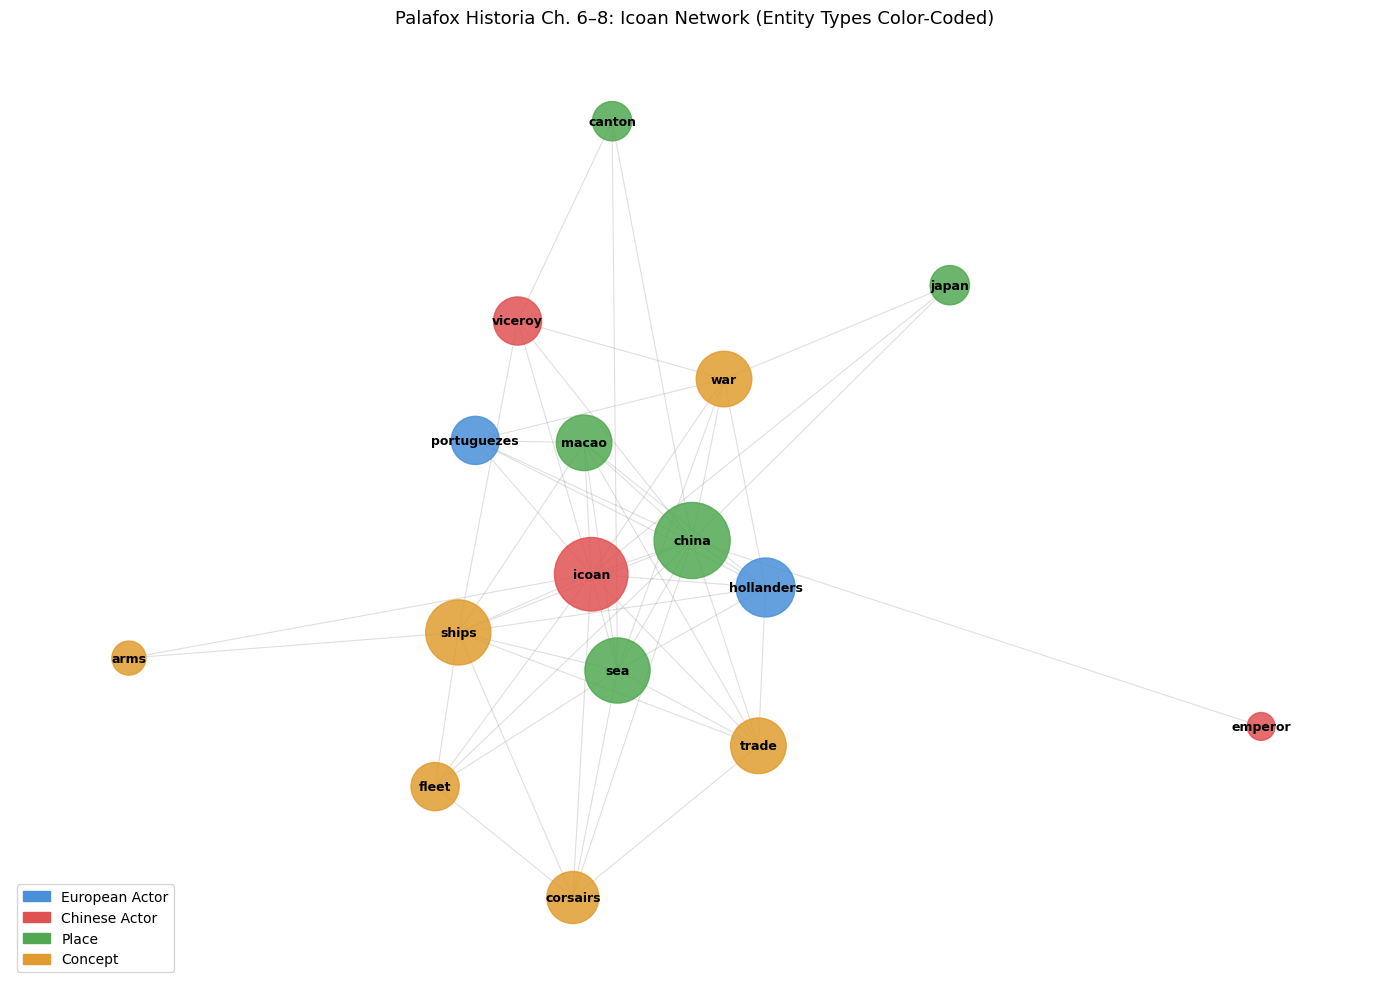

✓ Entity network saved to data/network_entity_ch6_8.png
  Note: layout algorithm may vary — structure matters, not exact positions
  Note: node sizes reflect degree centrality computed from actual network


In [ ]:
# PART 4 — Cell 23: Visualise color-coded entity network

fig, ax = plt.subplots(figsize=(14, 10))

# Remove isolates for clarity
G_vis = entity_network.copy()
G_vis.remove_nodes_from(list(nx.isolates(G_vis)))

pos = nx.spring_layout(G_vis, k=1.2, seed=42)

node_colors = [COLOR_MAP.get(ENTITY_TYPES.get(n, ''), '#aaaaaa') for n in G_vis.nodes()]
node_sizes  = [centrality.get(n, 0.01) * 3000 + 200 for n in G_vis.nodes()]

nx.draw_networkx_edges(G_vis, pos, ax=ax, alpha=0.25, width=0.8, edge_color='gray')
nx.draw_networkx_nodes(G_vis, pos, ax=ax, node_size=node_sizes,
                       node_color=node_colors, alpha=0.85)
nx.draw_networkx_labels(G_vis, pos, ax=ax, font_size=9, font_weight='bold')

# Legend
legend_patches = [mpatches.Patch(color=col, label=etype)
                  for etype, col in COLOR_MAP.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10)

ax.set_title("Palafox Historia Ch. 6–8: Icoan Network (Entity Types Color-Coded)",
             fontsize=13, pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig("data/network_entity_ch6_8.png", dpi=150)
plt.show()

print("✓ Entity network saved to data/network_entity_ch6_8.png")
print("  Note: layout algorithm may vary — structure matters, not exact positions")
print("  Note: node sizes reflect degree centrality computed from actual network")

---
## CHECKPOINT 4: Disciplinary Interpretation

**What the network shows** (from actual computed structure):
- Icoan has the highest centrality in the filtered network
- Icoan connects **European actors** (Hollanders, Portuguese) with **Chinese places** (Macao, Canton)
- This is a structural observation — Icoan is a *narrative hinge* between these two clusters

**Historical interpretation**:
- Palafox frames Icoan as a **third force**: neither straightforwardly Ming loyalist, nor Tartar, but a maritime-commercial actor whose story is embedded *between* the dynastic fall (Chs. 1–5) and the long corsair conflict (Chs. 10–21)
- The network structure reflects Palafox's **dual-theater narrative**: maritime-commercial conflict receives comparable structural prominence to dynastic conquest
- Palafox wrote from Mexico, at the Pacific nexus of empire — his sources arrived via Macao → Manila → Mexico City

**What this CANNOT tell us**:
- *Why* Palafox made this choice (requires archival context: sources, correspondence, position as Viceroy)
- Whether the account is historically accurate
- Authorial intent or unconscious biases — this is text structure, not mind

> **NOTE**: Same method, different questions.  
> Psycholinguistics maps **cognitive structure** (how the mind organises concepts).  
> History maps **narrative structure** (how an author organises events).  
> Both are valid — interpretation depends on what you are asking.

---
## PART 5: Limitations & Extensions

### What this method CANNOT tell us
- Whether Palafox's account is historically accurate
- Why he emphasised maritime actors (requires archival context)
- Authorial intent or unconscious biases
- Causation or historical processes

### What this method CAN do
- Flag distinctive passages for close reading (TF-IDF)
- Reveal narrative structure and thematic emphasis (segmentation)
- Identify structurally central actors (network centrality)
- Make interpretive choices **transparent** — stopwords, entity coding, thresholds are all visible and contestable

### Key principles
1. **Transparency**: show all manual inputs (stopwords, entity types, co-occurrence thresholds)
2. **Validation**: combine computation with close reading (TF-IDF → KWIC → interpretation)
3. **Segmentation**: units of analysis shape what patterns emerge — choose deliberately
4. **Interpretation**: networks describe structure; historians provide context

### Possible extensions
- Track entity co-occurrence across all 32 chapters (narrative arc over time)
- Apply to other colonial histories in the same EEBO-TCP corpus

---
## Try It Yourself

Adapt this workflow to your own historical texts:

1. **Choose corpus and research question**  
   What historiographic patterns do you want to investigate?

2. **Define units of analysis**  
   Chapters? Sections? Letters? Temporal segments? The choice shapes results.

3. **Establish keyword selection method**  
   Frequency, TF-IDF, or explicit domain lexicons — and justify the choice.

4. **Build networks with full transparency**  
   Document all thresholds, coding decisions, and interpretation logic.

5. **Validate computationally flagged patterns**  
   Return to the text. Connect to existing historiographic debates.

---
> **Remember**: Computational methods do not replace historical expertise —  
> they **scale and systematise** what historians already do.